## Authorship

- **Course / code author:** Xinze Li  
- **Tutorial article:** Xinze Li, Fanfan Lin, Juan J. Rodríguez-Andina, Sergio Vazquez, Homer Alan Mantooth, Leopoldo García Franquelo, "Fundamentals of Artificial Intelligences for Power Electronics," *IEEE Transactions on Industrial Electronics*, 2026.

*These learning resources are still under active refinement; notebooks, data, and documentation may change.*

---



## Preliminary if Using Google Colab

- Recommended method: use `pip` with `requirements.txt` at the repository root.
- If you are in **Google Colab**, run the next code cell once to clone this repo and install dependencies.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/XinzeLee/Fundamentals_of_AI_for_PE/blob/main/2_Classic_ML/ridge_polynomial_regression.ipynb)


In [1]:
import os
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    repo_dir = "/content/Fundamentals_of_AI_for_PE"
    if not os.path.isdir(repo_dir):
        !git clone https://github.com/XinzeLee/Fundamentals_of_AI_for_PE.git /content/Fundamentals_of_AI_for_PE
    %cd /content/Fundamentals_of_AI_for_PE
    !pip install -q -r requirements.txt
    os.chdir(os.path.join(repo_dir, "2_Classic_ML"))
else:
    print(
        "Not in Google Colab — skip clone/pip. Use your local env or run: pip install -r requirements.txt from the repo root."
    )


Not in Google Colab — skip clone/pip. Use your local env or run: pip install -r requirements.txt from the repo root.


# Polynomial Ridge regression and the bias–variance trade-off

This notebook uses **synthetic one-dimensional data** so we can visualize **underfitting**, **overfitting**, and a **well-regularized** fit side by side—before working with messier, higher-dimensional datasets in real PE use cases.


## 1. Regression problem we simulate

We observe pairs $(x_i, y_i)$ with a **scalar** input $x$. The data follow a **smooth nonlinear** function plus **Gaussian noise**. From a finite training set we want predictions that track the **noise-free** curve on held-out $x$, not the particular noise realization in the training labels.

**Why start in 1-D?** You can plot truth, data, and predictions together. The same qualitative story (bias vs. variance) carries over to multivariate regression.


## 2. Polynomial features and Ridge ($L_2$) regression

We map $x$ to a polynomial basis $\phi(x) = [1, x, x^2, \ldots, x^d]^\top$ and fit **Ridge** regression (linear least squares with an $L_2$ penalty on the coefficients):

$$\min_w \sum_i \bigl(y_i - w^\top \phi(x_i)\bigr)^2 + \alpha \|w\|_2^2$$

- **Degree $d$** controls how many basis terms you allow (more terms → more flexible fit).
- **Penalty $\alpha > 0$** pulls weights toward zero so the fit cannot chase noise as aggressively.

In code we chain `PolynomialFeatures` and `Ridge` inside one `sklearn.pipeline.Pipeline`.


## 3. Underfitting, overfitting, and a reasonable compromise

| Regime | Intuition | What you often see on train vs. test MSE |
|--------|-----------|------------------------------------------|
| **Underfitting** | Model too simple; misses shape of the truth | **Both** errors relatively **high** |
| **Overfitting** | Very flexible model + **too little** regularization; fits noise | Train **low**, test **much higher** |
| **Proper fit** | Enough flexibility **and** enough Ridge | Errors **moderate** and **closer together** |

The next cells build one synthetic dataset, then show **three deliberate** $(d, \alpha)$ choices illustrating these three regimes.


### 4. Build the dataset

Ground truth: $f(x) = 0.5 x^3 - x + 0.4\sin(5x)$ on $x \in [-1,1]$, plus i.i.d. Gaussian noise on $y$.


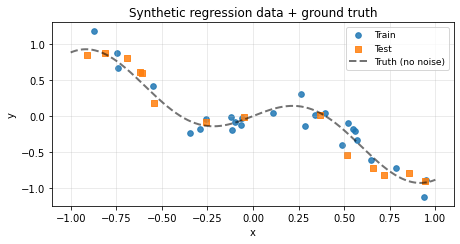

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(42)


def ground_truth(x: np.ndarray) -> np.ndarray:
    """Noise-free target (scalar or array)."""
    return 0.5 * x**3 - x + 0.4 * np.sin(5.0 * x)


n_samples = 40
X = rng.uniform(-1.0, 1.0, size=(n_samples, 1))
y = ground_truth(X.ravel()) + rng.normal(0.0, 0.18, size=n_samples)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.35, random_state=0
)

x_grid = np.linspace(-1.0, 1.0, 300).reshape(-1, 1)
y_true_grid = ground_truth(x_grid.ravel())

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.scatter(X_train.ravel(), y_train, s=32, label="Train", alpha=0.85)
ax.scatter(X_test.ravel(), y_test, s=32, marker="s", label="Test", alpha=0.85)
ax.plot(x_grid, y_true_grid, "k--", lw=2, alpha=0.55, label="Truth (no noise)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Synthetic regression data + ground truth")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 5. Fit three Ridge pipelines and compare

Same train/test split for all panels: **degree 1** (underfit), **degree 18** with tiny $\alpha$ (overfit), and **degree 18** with larger $\alpha$ (Ridge stabilizes the high-degree fit).


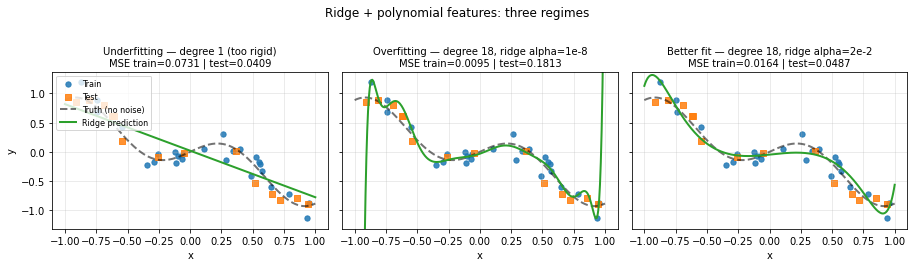

In [4]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures


def make_model(degree: int, alpha: float) -> Pipeline:
    return Pipeline(
        steps=[
            ("poly", PolynomialFeatures(degree=degree, include_bias=True)),
            ("ridge", Ridge(alpha=alpha)),
        ]
    )


scenarios = [
    ("Underfitting — degree 1 (too rigid)", 1, 1e-3),
    ("Overfitting — degree 18, ridge alpha=1e-8", 18, 1e-8),
    ("Better fit — degree 18, ridge alpha=2e-2", 18, 2e-2),
]

fig, axes = plt.subplots(1, 3, figsize=(12.8, 3.6), sharey=True)
# Find global y range for all data (true curve + y values)
y_min = min(np.min(y_true_grid), np.min(y_train), np.min(y_test))
y_max = max(np.max(y_true_grid), np.max(y_train), np.max(y_test))
# Expand a bit visually:
y_range = y_max - y_min
y_pad = 0.08 * y_range
y_lim = (y_min - y_pad, y_max + y_pad)

for ax, (title, deg, alpha) in zip(axes, scenarios):
    model = make_model(deg, alpha)
    model.fit(X_train, y_train)
    y_pred_tr = model.predict(X_train)
    y_pred_te = model.predict(X_test)
    y_line = model.predict(x_grid)

    mse_tr = mean_squared_error(y_train, y_pred_tr)
    mse_te = mean_squared_error(y_test, y_pred_te)

    ax.scatter(X_train.ravel(), y_train, s=28, alpha=0.85, label="Train", c="C0")
    ax.scatter(X_test.ravel(), y_test, s=28, alpha=0.85, marker="s", label="Test", c="C1")
    ax.plot(x_grid, y_true_grid, "k--", lw=2, alpha=0.55, label="Truth (no noise)")
    ax.plot(x_grid, y_line, "C2", lw=2, label="Ridge prediction")
    ax.set_title(title + f"\nMSE train={mse_tr:.4f} | test={mse_te:.4f}", fontsize=10)
    ax.set_xlabel("x")
    ax.grid(True, alpha=0.3)
    ax.set_ylim(y_lim)  # <-- Adapt the y-scale for each subplot

axes[0].set_ylabel("y")
axes[0].legend(loc="upper left", fontsize=8)
plt.suptitle("Ridge + polynomial features: three regimes", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()


### 6. Takeaway

- **Model complexity** (here: polynomial degree) and **regularization** (here: Ridge $\alpha$) interact: you can often fix an overly wiggly high-degree fit by **increasing $\alpha$**, not only by lowering the degree.
- Always check **generalization** (test or cross-validation), not just training error.
- **Next:** see `classic_ML.ipynb` in this folder for a classification workflow on real tabular data (decision trees).
